In [ ]:
#trend forecasting

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os
from dotenv import load_dotenv

load_dotenv()

full_model = load_model("models/fashion_cnn.keras")

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

@tf.function
def run_model(x):
    return full_model(x, training=False)

_ = run_model(np.zeros((1, 28, 28, 1), dtype=np.float32))
print("✅ Ready")


✅ Ready


In [2]:
(_, _), (X_test, y_test) = fashion_mnist.load_data()

np.random.seed(99)

# Simulate 8 weekly batches of 200 items each
weeks        = 8
items_per_week = 200
weekly_data  = []

# Inject realistic trends
# Sneaker demand rises weeks 5-8 (summer), Coat falls
trend_weights = {
    "Sneaker"    : [1.0, 1.0, 1.1, 1.2, 1.5, 1.8, 2.0, 2.2],
    "Coat"       : [2.0, 1.8, 1.6, 1.4, 1.2, 1.0, 0.8, 0.6],
    "Sandal"     : [0.8, 0.9, 1.0, 1.2, 1.5, 1.7, 1.9, 2.0],
    "Dress"      : [1.0, 1.0, 1.1, 1.3, 1.4, 1.5, 1.5, 1.6],
}

base_date = datetime(2026, 1, 5)  # Week 1 starts Jan 5

for week in range(weeks):
    week_date = base_date + timedelta(weeks=week)

    # Build weighted sampling
    weights = np.ones(len(X_test))
    for i, label in enumerate(y_test):
        cat = class_names[label]
        if cat in trend_weights:
            weights[i] = trend_weights[cat][week]

    weights = weights / weights.sum()
    indices = np.random.choice(len(X_test), items_per_week,
                               replace=False, p=weights)

    # Classify each item
    batch = (X_test[indices] / 255.0).astype(np.float32).reshape(-1, 28, 28, 1)
    preds = run_model(batch).numpy()
    pred_labels = [class_names[p.argmax()] for p in preds]

    for label in pred_labels:
        weekly_data.append({
            "week"      : week + 1,
            "week_date" : week_date.strftime("%Y-%m-%d"),
            "category"  : label
        })

df = pd.DataFrame(weekly_data)
print(f"✅ Generated {len(df)} records across {weeks} weeks")
print(df.groupby(["week", "category"]).size().unstack(fill_value=0))


✅ Generated 1600 records across 8 weeks
category  Ankle boot  Bag  Coat  Dress  Pullover  Sandal  Shirt  Sneaker  \
week                                                                       
1                 20   16    41     16        28      20     25       11   
2                 21   15    30     22        18      19     22       20   
3                 23   16    35     14        21      14     16       15   
4                 12   19    22     21        17      18     13       30   
5                 13   17    19     17        21      27     12       34   
6                 17   17    19     20        20      25     19       30   
7                 17   12    11     28        14      27     19       29   
8                 20   14    12     22        18      38     15       30   

category  T-shirt  Trouser  
week                        
1              13       10  
2              17       16  
3              23       23  
4              25       23  
5              23       1

In [ ]:
#weekly trends

In [3]:
# Weekly category counts
weekly_counts = (
    df.groupby(["week_date", "category"])
    .size()
    .reset_index(name="count")
)

# Week-over-week % change
weekly_counts = weekly_counts.sort_values(["category", "week_date"])
weekly_counts["prev_count"] = weekly_counts.groupby("category")["count"].shift(1)
weekly_counts["wow_change"] = (
    (weekly_counts["count"] - weekly_counts["prev_count"])
    / weekly_counts["prev_count"] * 100
).round(1)

# Latest week trend summary
latest_week = weekly_counts["week_date"].max()
trend_summary = (
    weekly_counts[weekly_counts["week_date"] == latest_week]
    [["category", "count", "wow_change"]]
    .sort_values("wow_change", ascending=False)
)

print(f"📊 Trend Summary — Week of {latest_week}")
print("─" * 45)
print(trend_summary.to_string(index=False))


📊 Trend Summary — Week of 2026-02-23
─────────────────────────────────────────────
  category  count  wow_change
    Sandal     38        40.7
  Pullover     18        28.6
Ankle boot     20        17.6
       Bag     14        16.7
      Coat     12         9.1
   Sneaker     30         3.4
     Shirt     15       -21.1
     Dress     22       -21.4
   T-shirt     14       -22.2
   Trouser     17       -32.0


What this tells a business
Stock up on: Sandals, Pullovers, Ankle boots — demand is growing fast

Reduce orders for: Trousers, T-shirts, Shirts — demand dropping sharply

Watch: Sneakers plateauing at +3.4% after rising for weeks — may peak soon

Opportunity: Sandal demand at +40.7% is the strongest signal — a real retailer would immediately push promotions and increase stock

/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_10746/1431106309.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_10746/1431106309.py:45: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_10746/1431106309.py:46: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("trend_forecast.png", dpi=150, bbox_inches="tight")
/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_10746/1431106309.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("trend_forecast.png", dpi=150, bbox_inches="tight")
/Users/sunerawanni/Desktop/databricks/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}

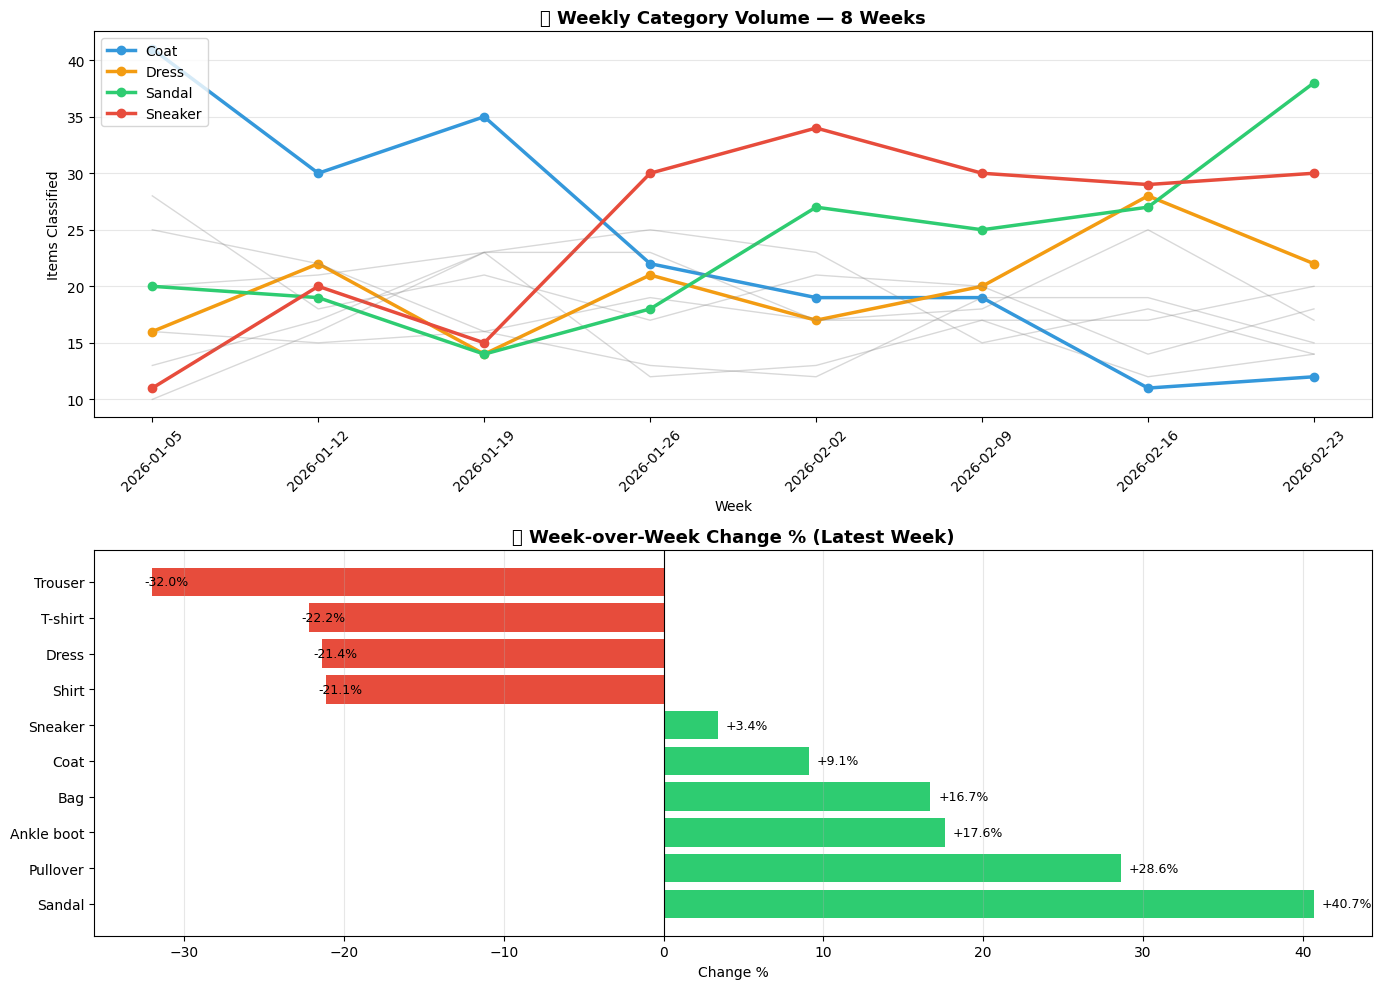

In [4]:
#visulaization of trends

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Plot 1: Weekly volume by category (line chart) ────────────────────────────
pivot = weekly_counts.pivot(index="week_date", columns="category", values="count").fillna(0)

highlight = ["Sneaker", "Coat", "Sandal", "Dress"]
colors    = {"Sneaker": "#e74c3c", "Coat": "#3498db",
             "Sandal" : "#2ecc71", "Dress": "#f39c12"}

for cat in pivot.columns:
    if cat in highlight:
        axes[0].plot(pivot.index, pivot[cat], marker="o",
                     linewidth=2.5, label=cat, color=colors[cat])
    else:
        axes[0].plot(pivot.index, pivot[cat], linewidth=1,
                     alpha=0.3, color="gray")

axes[0].set_title("📈 Weekly Category Volume — 8 Weeks", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Items Classified")
axes[0].legend(loc="upper left")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# ── Plot 2: Latest week WoW change bar chart ──────────────────────────────────
colors_bar = ["#2ecc71" if x >= 0 else "#e74c3c"
              for x in trend_summary["wow_change"].fillna(0)]

axes[1].barh(trend_summary["category"],
             trend_summary["wow_change"].fillna(0),
             color=colors_bar)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("📊 Week-over-Week Change % (Latest Week)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Change %")
axes[1].grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(trend_summary.iterrows()):
    val = row["wow_change"]
    if pd.notna(val):
        axes[1].text(val + 0.5 if val >= 0 else val - 0.5, i,
                     f"{val:+.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("trend_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


Top Chart — Weekly Volume (Line Chart)
This answers: "What is selling week by week?"

🔴 Sneaker — started low at 11, climbed steadily to 30 → summer demand building

🟢 Sandal — exploded in the last 2 weeks from 25 → 38 → strongest growth signal

🔵 Coat — peaked at 35 in week 3 then crashed to 12 → winter season clearly ending

🟡 Dress — relatively stable around 18-22 → consistent but not exciting

Business action: Start clearing coat inventory now before it drops further. Push sandal and sneaker stock to the front of the store/website.

Bottom Chart — Week-over-Week Change (Bar Chart)
This answers: "What changed THIS week vs last week?"

🟥 Trouser -32% → biggest single-week drop — stop reordering immediately

🟥 T-shirt -22%, Dress -21%, Shirt -21% → all falling together — post-January slump

🟩 Sandal +40.7% → strongest buy signal of the entire season

🟩 Pullover +28.6% → surprising rise — possibly early spring transitional wear



### saving trend data locally

In [5]:
weekly_counts.to_csv("trend_forecast_data.csv", index=False)
print("✅ Trend data saved → trend_forecast_data.csv")
print(f"\n🔥 Rising categories  : {trend_summary[trend_summary['wow_change'] > 0]['category'].tolist()}")
print(f"📉 Falling categories : {trend_summary[trend_summary['wow_change'] < 0]['category'].tolist()}")


✅ Trend data saved → trend_forecast_data.csv

🔥 Rising categories  : ['Sandal', 'Pullover', 'Ankle boot', 'Bag', 'Coat', 'Sneaker']
📉 Falling categories : ['Shirt', 'Dress', 'T-shirt', 'Trouser']
